<a href="https://colab.research.google.com/github/Sameh184/Diabetes_repo/blob/main/Diabetes_Prediction_Model_Domain_Decision_Tree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
#Reading the data and inspecting it
import pandas as pd
dataset = pd.read_csv('/content/Diabetes Dataset (1).csv')
print(dataset.head())
print(dataset.info())
print(dataset.describe())
print(dataset['CLASS'].value_counts())
print(dataset['Gender'].value_counts())



#Gender needs to be encoded along with the target variable.


#The Yes values in the data set are way more than the no and the P meaning that we have about an 80-20 imbalance of data which could cause the model to be biased.

    ID  No_Pation Gender  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL  \
0  502      17975      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
1  735      34221      M   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6   
2  420      47975      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
3  680      87656      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5   
4  504      34223      M   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4   

    BMI CLASS  
0  24.0     N  
1  23.0     N  
2  24.0     N  
3  24.0     N  
4  21.0     N  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1000 non-null   int64  
 1   No_Pation  1000 non-null   int64  
 2   Gender     1000 non-null   object 
 3   AGE        1000 non-null   int64  
 4   Urea       1000 non-null   float64
 5   Cr         1000 non-null   int64  
 6   HbA1c     

In [28]:
#Data cleaning

dataset["CLASS"] = dataset["CLASS"].replace("Y " , "Y")
dataset["CLASS"] = dataset["CLASS"].replace("N " , "N")
dataset["Gender"] = dataset["Gender"].replace("f" , "F")
print(dataset['CLASS'].value_counts())
print(dataset['Gender'].value_counts())


#Removing useless columns
dataset = dataset.drop(axis= 1 , columns=["ID" , "No_Pation" ])

print(dataset.head())
print(dataset.shape)

#Checking if there are any missing values
print(dataset.isna().sum())


CLASS
Y    844
N    103
P     53
Name: count, dtype: int64
Gender
M    565
F    435
Name: count, dtype: int64
  Gender  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI CLASS
0      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
1      M   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6  23.0     N
2      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
3      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
4      M   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4  21.0     N
(1000, 12)
Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [29]:
print("--- Outlier Report ---")

numerical_columns_to_check = ["AGE", "Urea", "Cr", "HbA1c", "Chol", "TG", "HDL", "LDL", "VLDL", "BMI"]

cleaned_dataset = dataset.copy()

for col in numerical_columns_to_check:
    Q1 = cleaned_dataset[col].quantile(0.25)
    Q3 = cleaned_dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - (1.5 * IQR)
    upper_bound = Q3 + (1.5 * IQR)

    outliers_low = (cleaned_dataset[col] < lower_bound).sum()
    outliers_high = (cleaned_dataset[col] > upper_bound).sum()
    total_outliers = outliers_low + outliers_high

    print(f"Column: {col}")
    print(f"  Bounds:    [{lower_bound:.2f} , {upper_bound:.2f}]")
    print(f"  Outliers:  {total_outliers} (Low: {outliers_low}, High: {outliers_high})\n")
    # removing outliers
    dataset = cleaned_dataset[
        (cleaned_dataset[col] >= lower_bound) &
        (cleaned_dataset[col] <= upper_bound)
    ]
    # FIX: carry the filtered rows forward so outlier removal accumulates
    # across columns instead of only reflecting the last column processed.
    cleaned_dataset = dataset.copy()

print(f"Final dataset shape after cumulative outlier removal: {dataset.shape}")

--- Outlier Report ---
Column: AGE
  Bounds:    [39.00 , 71.00]
  Outliers:  98 (Low: 79, High: 19)

Column: Urea
  Bounds:    [0.70 , 8.70]
  Outliers:  59 (Low: 1, High: 58)

Column: Cr
  Bounds:    [8.50 , 108.50]
  Outliers:  10 (Low: 0, High: 10)

Column: HbA1c
  Bounds:    [1.55 , 15.55]
  Outliers:  6 (Low: 4, High: 2)

Column: Chol
  Bounds:    [1.60 , 8.00]
  Outliers:  24 (Low: 3, High: 21)

Column: TG
  Bounds:    [-0.60 , 5.00]
  Outliers:  40 (Low: 0, High: 40)

Column: HDL
  Bounds:    [0.30 , 1.90]
  Outliers:  40 (Low: 1, High: 39)

Column: LDL
  Bounds:    [-0.45 , 5.55]
  Outliers:  3 (Low: 0, High: 3)

Column: VLDL
  Bounds:    [-0.35 , 2.45]
  Outliers:  42 (Low: 0, High: 42)

Column: BMI
  Bounds:    [15.50 , 43.50]
  Outliers:  0 (Low: 0, High: 0)

Final dataset shape after cumulative outlier removal: (678, 12)


In [30]:
#Feature transformation
dataset['CLASS'] = dataset['CLASS'].astype('category').cat.codes
dataset['Gender'] = dataset['Gender'].astype('category').cat.codes


dataset.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
5,0,45,2.3,24,4.0,2.9,1.0,1.0,1.5,0.4,21.0,0
6,0,50,2.0,50,4.0,3.6,1.3,0.9,2.1,0.6,24.0,0
7,1,48,4.7,47,4.0,2.9,0.8,0.9,1.6,0.4,24.0,0
13,0,45,4.6,54,5.1,4.2,1.7,1.2,2.2,0.8,23.0,0
14,0,50,3.5,39,4.0,4.0,1.5,1.2,2.2,0.7,24.0,0


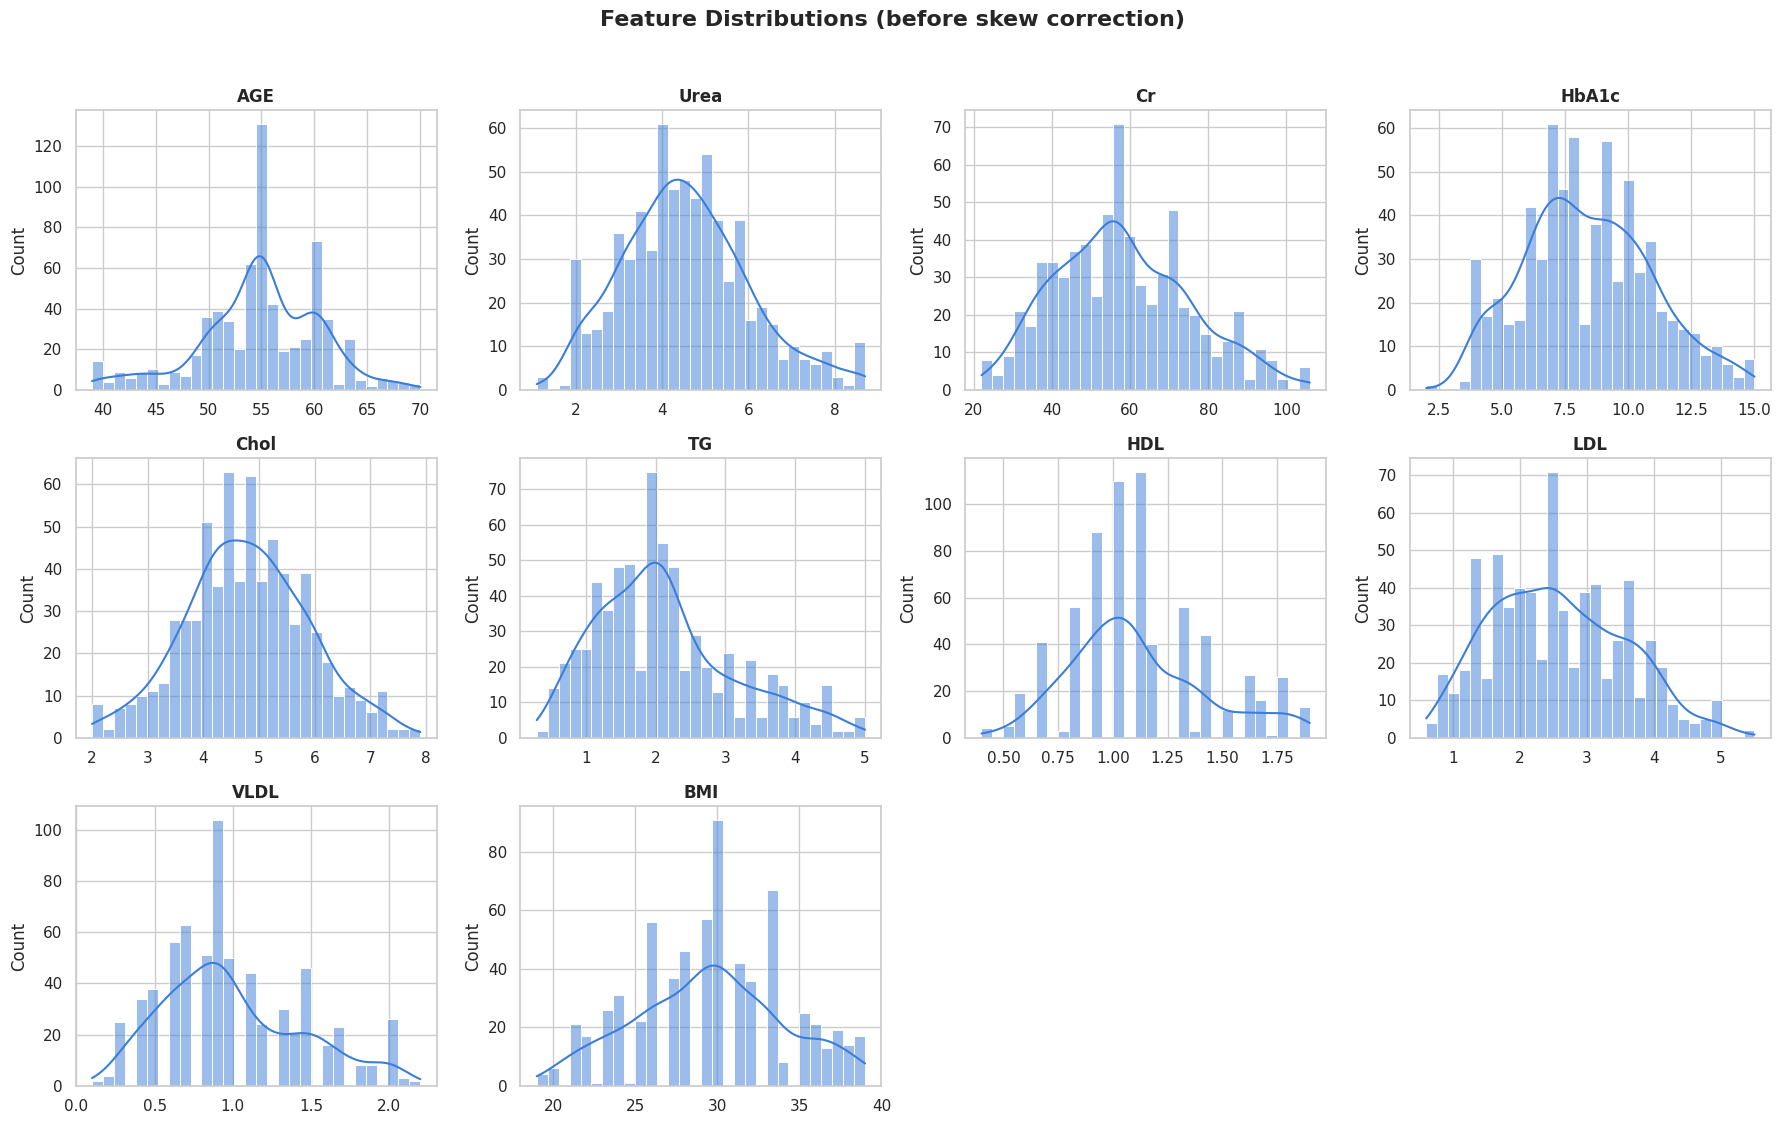

Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [31]:
#Plot histograms to show skewness
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")

numerical_columns = dataset.select_dtypes(exclude="object")
numerical_columns = numerical_columns.drop(axis=1 , columns=["Gender" , "CLASS"])

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for ax, col in zip(axes, numerical_columns.columns):
    sns.histplot(numerical_columns[col], bins=30, kde=True, color="#3b7dd8", ax=ax, edgecolor="white")
    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
for ax in axes[len(numerical_columns.columns):]:
    ax.axis("off")
fig.suptitle("Feature Distributions (before skew correction)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print(dataset.isna().sum())

#The following columns are skewed => Urea , Cr , TG , VLDL , HDL , LDL

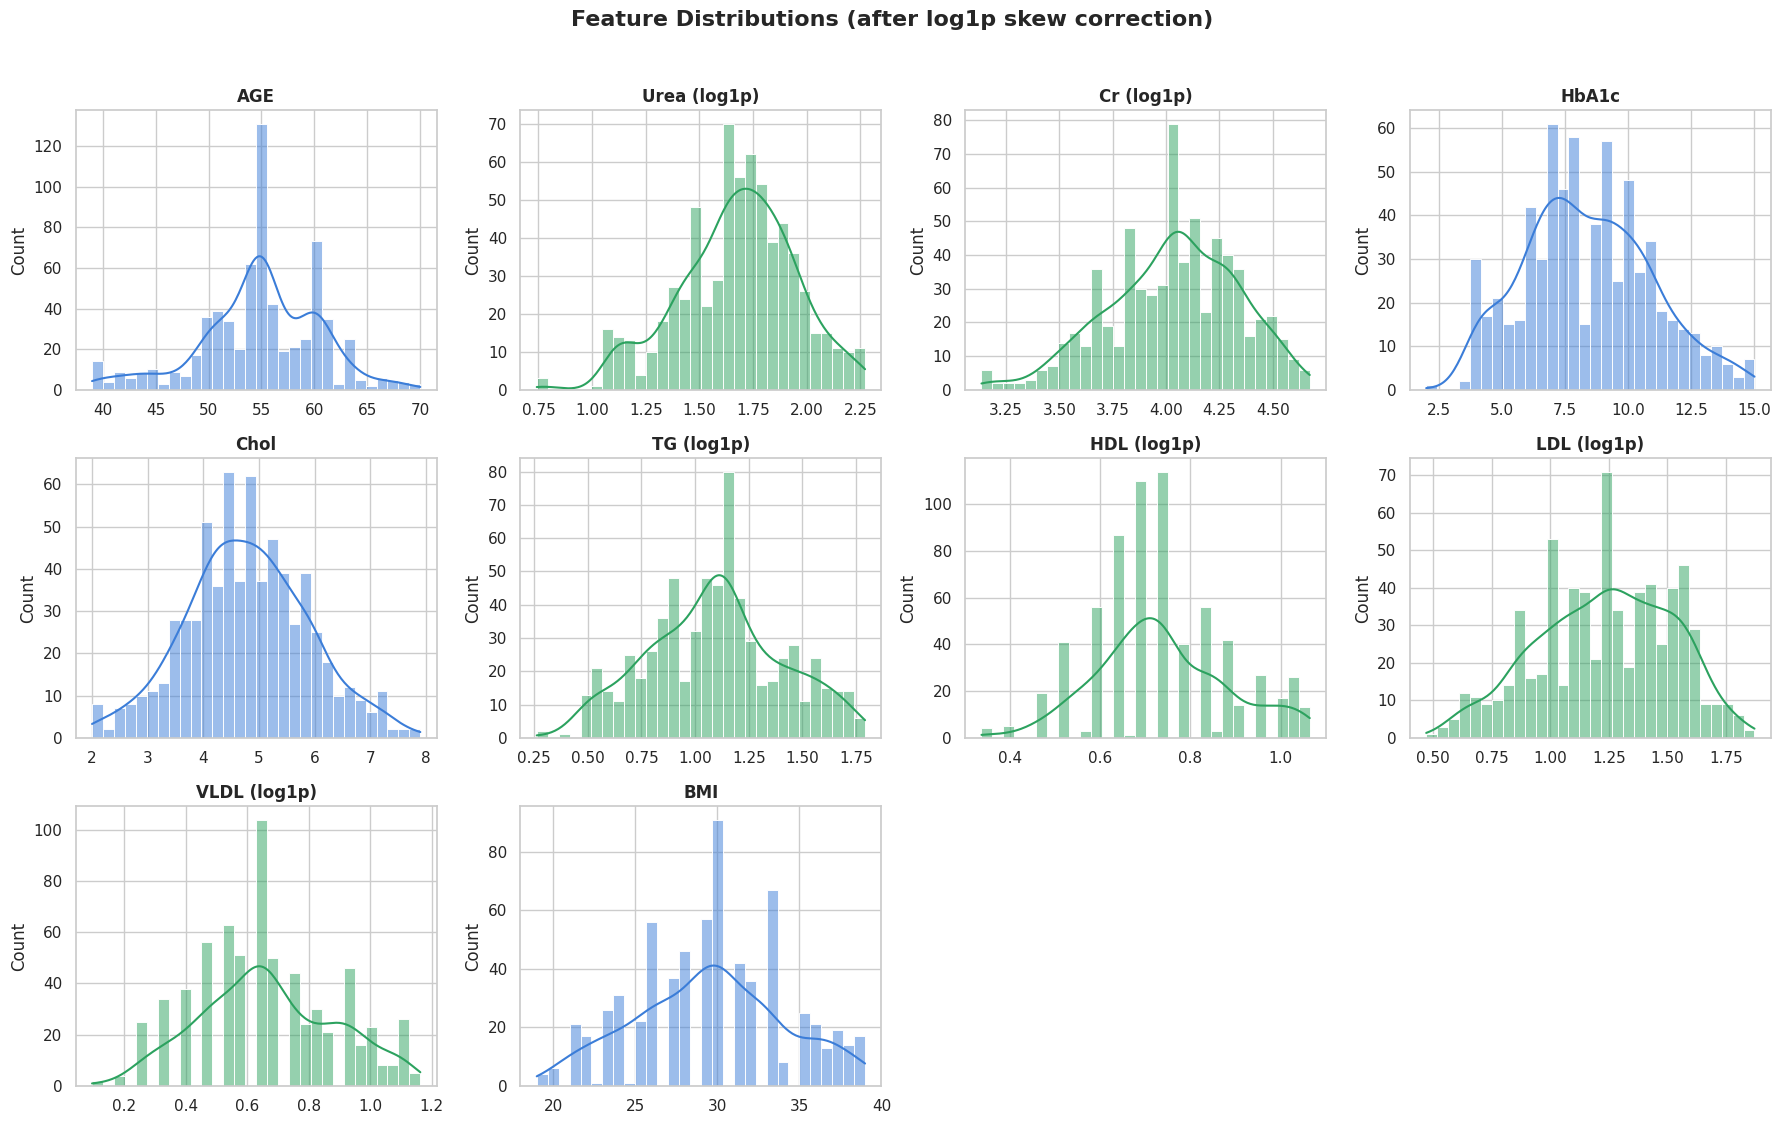

Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


In [32]:
# # Fixing skewness
import numpy as np

skewed_columns = [ "VLDL" , "HDL" , "Urea", "Cr" , "LDL" , "TG"]
for column in skewed_columns:
    dataset[column] = np.log1p(dataset[column])
numerical_columns = dataset.select_dtypes(exclude="object")
numerical_columns = numerical_columns.drop(axis=1 , columns=["Gender" , "CLASS"])

fig, axes = plt.subplots(3, 4, figsize=(18, 11))
axes = axes.flatten()
for ax, col in zip(axes, numerical_columns.columns):
    is_transformed = col in skewed_columns
    color = "#2ca25f" if is_transformed else "#3b7dd8"
    sns.histplot(numerical_columns[col], bins=30, kde=True, color=color, ax=ax, edgecolor="white")
    ax.set_title(col + (" (log1p)" if is_transformed else ""), fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Count")
for ax in axes[len(numerical_columns.columns):]:
    ax.axis("off")
fig.suptitle("Feature Distributions (after log1p skew correction)", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()
print(dataset.isna().sum())

In [33]:
dataset.head()

,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
5,0,45,1.193922,3.218876,4.0,2.9,0.693147,0.693147,0.916291,0.336472,21.0,0
6,0,50,1.098612,3.931826,4.0,3.6,0.832909,0.641854,1.131402,0.470004,24.0,0
7,1,48,1.740466,3.871201,4.0,2.9,0.587787,0.641854,0.955511,0.336472,24.0,0
13,0,45,1.722767,4.007333,5.1,4.2,0.993252,0.788457,1.163151,0.587787,23.0,0
14,0,50,1.504077,3.688879,4.0,4.0,0.916291,0.788457,1.163151,0.530628,24.0,0


In [34]:
#Divide our data into 3 groups
from scipy.stats import f_oneway

group_Y = dataset[dataset["CLASS"] == 1]
group_N = dataset[dataset["CLASS"] == 0]
group_P = dataset[dataset["CLASS"] == 2]
anovaColumns = ["AGE" , "Urea" , "Cr" , "HbA1c" ,"Chol" , "TG" , "HDL" , "LDL" , "VLDL" , "BMI" , "Gender"]
for column in anovaColumns:
    f_statistic, p_value = f_oneway(group_N[column] , group_P[column] , group_Y[column])
    print(f"Column : {column} , p_value : {p_value}")

#Any value lower than 0.05 means that this column can be used very well to diffrentiate between different target values => AGE , HbA1c , Chol , TG , VLDL , BMI, Urea ,Gender

Column : AGE , p_value : 7.577513666397487e-51
Column : Urea , p_value : 0.42528287538455734
Column : Cr , p_value : 0.6296991977575055
Column : HbA1c , p_value : 7.923968747656728e-47
Column : Chol , p_value : 0.00018709797229422926
Column : TG , p_value : 2.8951399027271677e-09
Column : HDL , p_value : 0.41218444625499007
Column : LDL , p_value : 0.3910836031248651
Column : VLDL , p_value : 7.391454000338725e-06
Column : BMI , p_value : 3.642215933896432e-58
Column : Gender , p_value : 0.008258291092678291


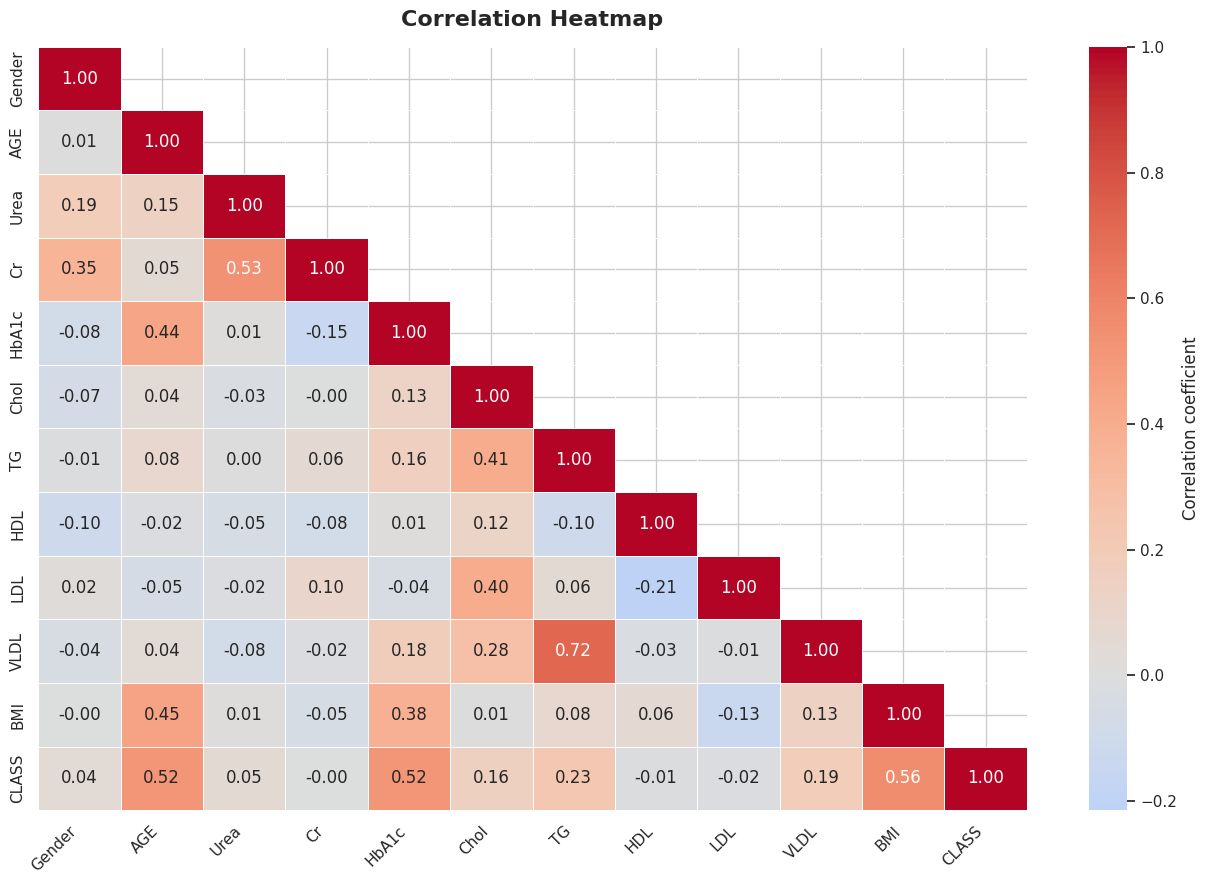

In [35]:
import seaborn as sns
import numpy as np

corr = dataset.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(13, 9))
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "Correlation coefficient"}
)
plt.title("Correlation Heatmap", fontsize=16, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
#Plotting the heatmap to display correlations and see if there is any multicolinearity
#Urea => CR

In [36]:
# Decision Tree Version 1: domain-knowledge discretization
# Re-read the original Colab dataset so medical cutoffs use clinical-scale values,
# not the log-transformed values from the exploratory phase-1 cells above.
import numpy as np
import pandas as pd

df_domain = pd.read_csv('/content/Diabetes Dataset (1).csv')
df_domain["CLASS"] = df_domain["CLASS"].astype(str).str.strip().str.upper()
df_domain["Gender"] = df_domain["Gender"].replace("f", "F")
df_domain = df_domain.drop(axis=1, columns=["ID", "No_Pation"])

print(df_domain.head())
print(df_domain["CLASS"].value_counts())
print(df_domain["Gender"].value_counts())


def discretize_domain(df):
    data = df.copy()

    cutoffs = {
        "Urea": [-np.inf, 2.5, 7.1, np.inf],
        "Cr": [-np.inf, 50, 110, np.inf],
        "HbA1c": [-np.inf, 5.7, 6.4, np.inf],
        "Chol": [-np.inf, 5.2, 6.2, np.inf],
        "TG": [-np.inf, 1.7, 2.2, np.inf],
        "HDL": [-np.inf, 1.0, 1.6, np.inf],
        "LDL": [-np.inf, 2.6, 4.1, np.inf],
        "VLDL": [-np.inf, 0.78, np.inf],
        "BMI": [-np.inf, 18.5, 25, 30, np.inf],
        "AGE": [-np.inf, 39, 59, np.inf],
    }

    labels = {
        "Urea": ["Low", "Normal", "High"],
        "Cr": ["Low", "Normal", "High"],
        "HbA1c": ["Normal", "Pre-diabetes", "Diabetes"],
        "Chol": ["Normal", "Borderline", "High"],
        "TG": ["Normal", "Borderline", "High"],
        "HDL": ["Low", "Normal", "High"],
        "LDL": ["Optimal", "Borderline", "High"],
        "VLDL": ["Normal", "High"],
        "BMI": ["Underweight", "Normal", "Overweight", "Obese"],
        "AGE": ["Early Adult", "Middle-Aged", "Senior"],
    }

    for col, bins in cutoffs.items():
        if col in data.columns:
            data[col] = pd.cut(data[col], bins=bins, labels=labels[col])

    return data


df_domain_binned = discretize_domain(df_domain)
df_domain_binned.head()

  Gender  AGE  Urea  Cr  HbA1c  Chol   TG  HDL  LDL  VLDL   BMI CLASS
0      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
1      M   26   4.5  62    4.9   3.7  1.4  1.1  2.1   0.6  23.0     N
2      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
3      F   50   4.7  46    4.9   4.2  0.9  2.4  1.4   0.5  24.0     N
4      M   33   7.1  46    4.9   4.9  1.0  0.8  2.0   0.4  21.0     N
CLASS
Y    844
N    103
P     53
Name: count, dtype: int64
Gender
M    565
F    435
Name: count, dtype: int64


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,Middle-Aged,Normal,Low,Normal,Normal,Normal,High,Optimal,Normal,Normal,N
1,M,Early Adult,Normal,Normal,Normal,Normal,Normal,Normal,Optimal,Normal,Normal,N
2,F,Middle-Aged,Normal,Low,Normal,Normal,Normal,High,Optimal,Normal,Normal,N
3,F,Middle-Aged,Normal,Low,Normal,Normal,Normal,High,Optimal,Normal,Normal,N
4,M,Early Adult,Normal,Low,Normal,Normal,Normal,Low,Optimal,Normal,Normal,N


In [37]:
mapping_dict = {
    "Gender": {"F": 0, "M": 1},
    "CLASS": {"N": 0, "P": 1, "Y": 2},
    "Urea": {"Low": 0, "Normal": 1, "High": 2},
    "Cr": {"Low": 0, "Normal": 1, "High": 2},
    "HbA1c": {"Normal": 0, "Pre-diabetes": 1, "Diabetes": 2},
    "Chol": {"Normal": 0, "Borderline": 1, "High": 2},
    "TG": {"Normal": 0, "Borderline": 1, "High": 2},
    "HDL": {"Low": 0, "Normal": 1, "High": 2},
    "LDL": {"Optimal": 0, "Borderline": 1, "High": 2},
    "VLDL": {"Normal": 0, "High": 1},
    "BMI": {"Underweight": 0, "Normal": 1, "Overweight": 2, "Obese": 3},
    "AGE": {"Early Adult": 0, "Middle-Aged": 1, "Senior": 2},
}

for col, mapping in mapping_dict.items():
    if col in df_domain_binned.columns:
        df_domain_binned[col] = df_domain_binned[col].map(mapping).astype(int)

print(df_domain_binned.isnull().sum())
df_domain_binned.head()

Gender    0
AGE       0
Urea      0
Cr        0
HbA1c     0
Chol      0
TG        0
HDL       0
LDL       0
VLDL      0
BMI       0
CLASS     0
dtype: int64


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,0,1,1,0,0,0,0,2,0,0,1,0
1,1,0,1,1,0,0,0,1,0,0,1,0
2,0,1,1,0,0,0,0,2,0,0,1,0
3,0,1,1,0,0,0,0,2,0,0,1,0
4,1,0,1,0,0,0,0,0,0,0,1,0


In [38]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

x_domain = df_domain_binned.drop(columns=["CLASS"])
y_domain = df_domain_binned["CLASS"]

x_train_domain, x_test_domain, y_train_domain, y_test_domain = train_test_split(
    x_domain,
    y_domain,
    test_size=0.3,
    shuffle=True,
    random_state=42,
    stratify=y_domain,
)

featuresToUse = ["AGE", "HbA1c", "Chol", "TG", "VLDL", "BMI", "Urea", "Gender"]
x_train_f = x_train_domain[featuresToUse]
x_test_f = x_test_domain[featuresToUse]

target_labels = [0, 1, 2]
target_names = ["Normal", "Pre-Diabetes", "Diabetes"]


def evaluate_domain_tree(model, model_name, plot=False):
    model.fit(x_train_f, y_train_domain)
    y_pred = model.predict(x_test_f)

    print(f"\n=== {model_name} ===")
    print("Accuracy:", accuracy_score(y_test_domain, y_pred))

    print("\nFeature Importances:")
    for name, score in zip(featuresToUse, model.feature_importances_):
        print(f"{name}: {score:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test_domain,
            y_pred,
            labels=target_labels,
            target_names=target_names,
            zero_division=0,
        )
    )

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test_domain, y_pred, labels=target_labels))

    if plot:
        plt.figure(figsize=(20, 10))
        plot_tree(
            model,
            feature_names=featuresToUse,
            class_names=target_names,
            filled=True,
            rounded=True,
            fontsize=10,
        )
        plt.title(model_name)
        plt.show()

    return model


=== Domain Decision Tree - Entropy, Max Depth 3 ===
Accuracy: 0.9266666666666666

Feature Importances:
AGE: 0.0000
HbA1c: 0.9296
Chol: 0.0000
TG: 0.0000
VLDL: 0.0000
BMI: 0.0704
Urea: 0.0000
Gender: 0.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       0.82      1.00      0.90        31
Pre-Diabetes       0.50      0.94      0.65        16
    Diabetes       1.00      0.92      0.96       253

    accuracy                           0.93       300
   macro avg       0.77      0.95      0.84       300
weighted avg       0.95      0.93      0.93       300


Confusion Matrix:
[[ 31   0   0]
 [  1  15   0]
 [  6  15 232]]


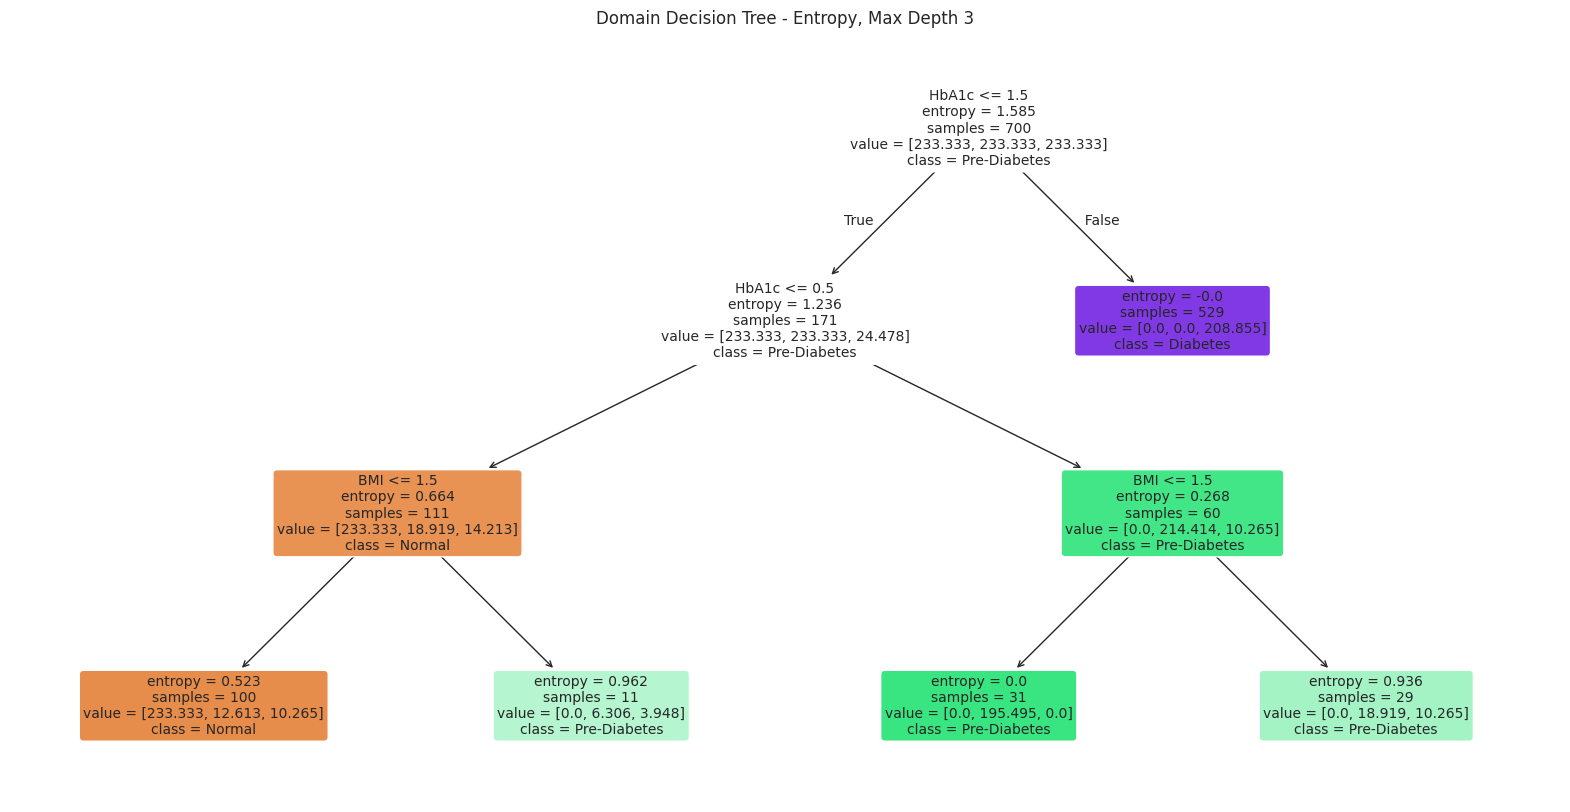

In [39]:
dt_depth3 = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42, class_weight='balanced')
dt_depth3 = evaluate_domain_tree(dt_depth3, "Domain Decision Tree - Entropy, Max Depth 3", plot=True)


=== Domain Decision Tree - Entropy, Max Depth 5 ===
Accuracy: 0.9766666666666667

Feature Importances:
AGE: 0.0035
HbA1c: 0.8764
Chol: 0.0291
TG: 0.0098
VLDL: 0.0077
BMI: 0.0664
Urea: 0.0070
Gender: 0.0000

Classification Report:
              precision    recall  f1-score   support

      Normal       0.86      1.00      0.93        31
Pre-Diabetes       0.93      0.88      0.90        16
    Diabetes       1.00      0.98      0.99       253

    accuracy                           0.98       300
   macro avg       0.93      0.95      0.94       300
weighted avg       0.98      0.98      0.98       300


Confusion Matrix:
[[ 31   0   0]
 [  1  14   1]
 [  4   1 248]]


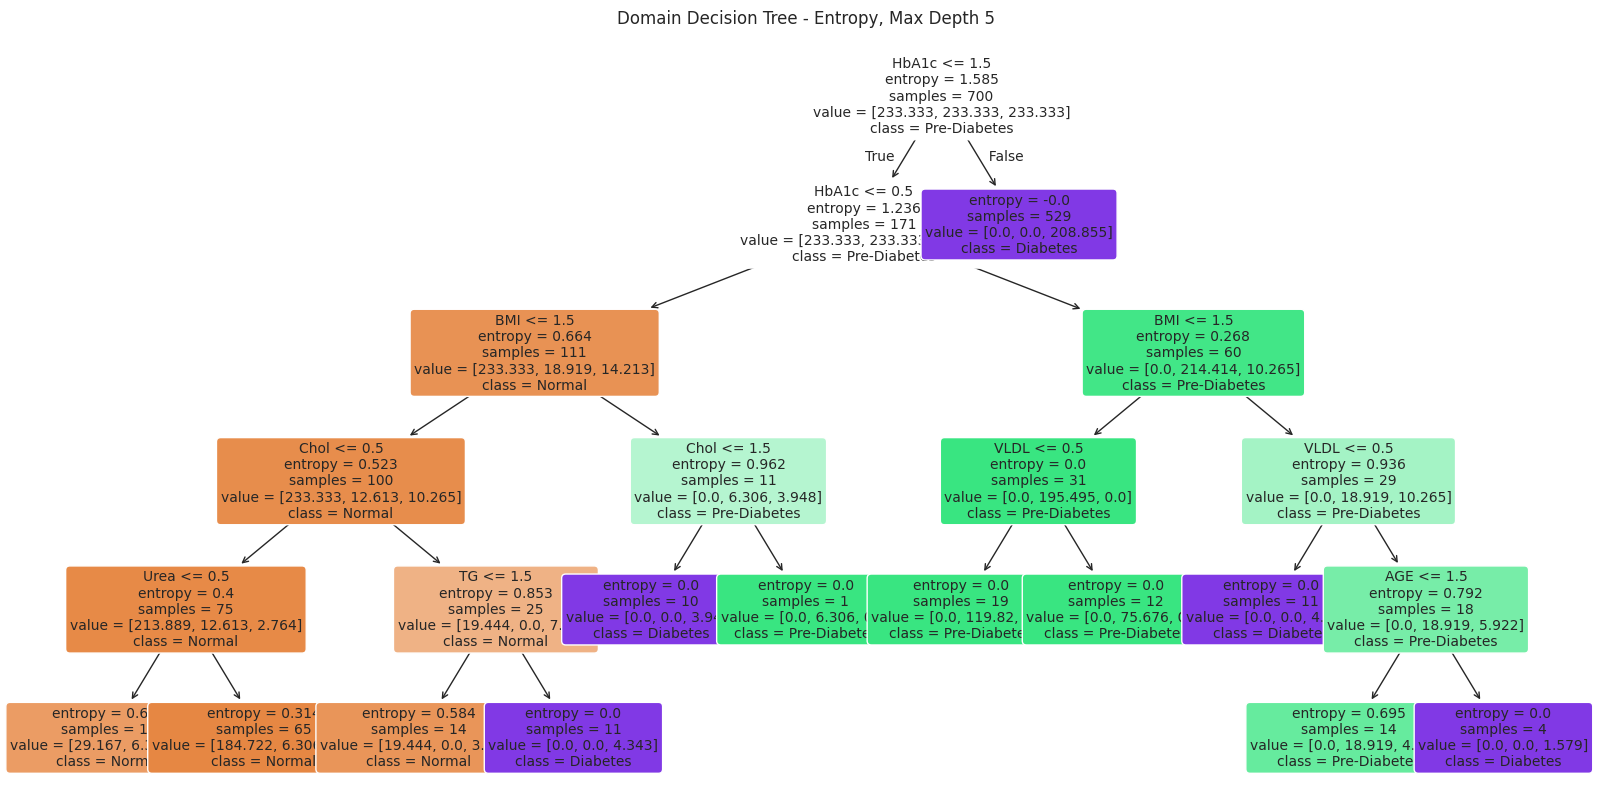

In [40]:
dt_depth5 = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42, class_weight='balanced')
dt_depth5 = evaluate_domain_tree(dt_depth5, "Domain Decision Tree - Entropy, Max Depth 5", plot=True)

Best Params: {'class_weight': 'balanced', 'criterion': 'entropy', 'max_depth': 10}
Best Cross-Val Score: 0.9104237917078445

=== Domain Decision Tree - Best Grid Search Model ===
Accuracy: 0.98

Feature Importances:
AGE: 0.0187
HbA1c: 0.8074
Chol: 0.0192
TG: 0.0455
VLDL: 0.0142
BMI: 0.0674
Urea: 0.0124
Gender: 0.0151

Classification Report:
              precision    recall  f1-score   support

      Normal       0.94      0.97      0.95        31
Pre-Diabetes       0.80      1.00      0.89        16
    Diabetes       1.00      0.98      0.99       253

    accuracy                           0.98       300
   macro avg       0.91      0.98      0.94       300
weighted avg       0.98      0.98      0.98       300


Confusion Matrix:
[[ 30   1   0]
 [  0  16   0]
 [  2   3 248]]


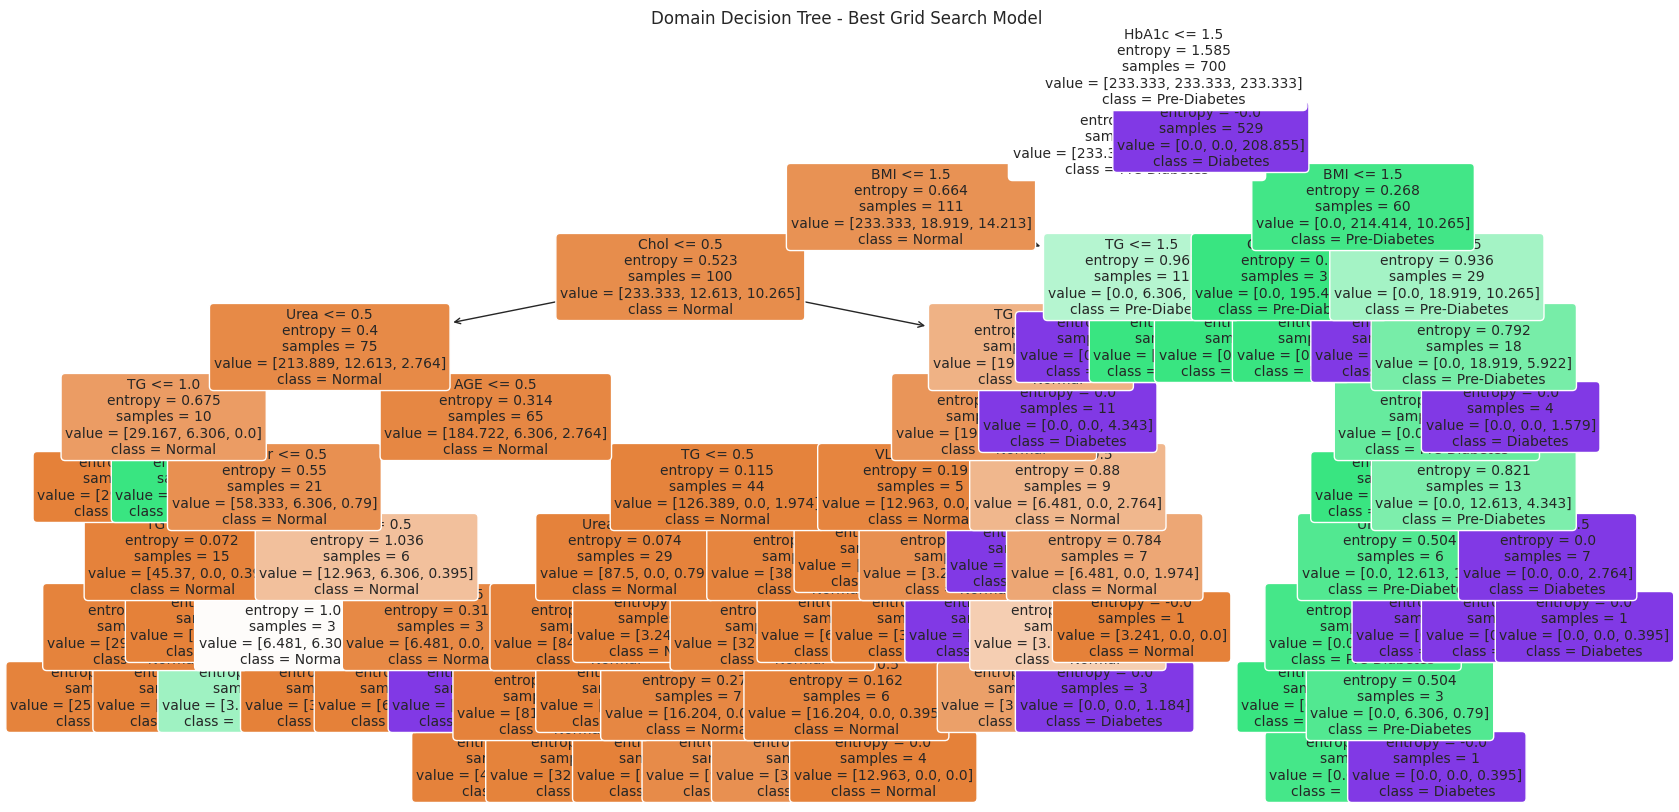

In [41]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 4, 5, 6, 8, 10, None],
    "class_weight": ["balanced"],
}

grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
)

grid_search.fit(x_train_f, y_train_domain)

print("Best Params:", grid_search.best_params_)
print("Best Cross-Val Score:", grid_search.best_score_)

best_domain_tree = evaluate_domain_tree(
    grid_search.best_estimator_,
    "Domain Decision Tree - Best Grid Search Model",
    plot=True,
)